# Day 5 Mini-Project: Titanic Survival Classification

This notebook builds a complete supervised-learning pipeline using the Titanic dataset from `week1/day4/train.csv`. The goal is to predict whether a passenger survived.

**Pipeline:** EDA → train/test split → leakage-safe preprocessing → cross-validated model comparison → final test evaluation.

## 1. Problem definition and metric

`Survived` is binary (`0 = did not survive`, `1 = survived`), so this is a **classification** task.

The primary metric is **F1-score for the survivor class**. Accuracy alone can look acceptable when the classes are uneven, while F1 balances precision (how often predicted survivors truly survived) and recall (how many actual survivors were found). Accuracy, precision, recall, and ROC AUC are also reported for context.

A most-frequent-class dummy classifier is used as the baseline. A useful model should clearly beat it.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load and inspect the data

The path check below makes the notebook work whether it is launched from the repository root or from this notebook's folder.

In [2]:
candidate_paths = [
    Path("../../week1/day4/train.csv"),
    Path("week1/day4/train.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find week1/day4/train.csv")

df = pd.read_csv(data_path)
print(f"Dataset: {data_path.resolve()}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset: C:\Users\A TO Z\Desktop\Code\BinX_Internship\week1\day4\train.csv
Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(1),
    "unique": df.nunique(),
})
summary

,dtype,missing,missing_%,unique
PassengerId,int64,0,0.0,891
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,str,0,0.0,891
Sex,str,0,0.0,2
Age,float64,177,19.9,88
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,str,0,0.0,681
Fare,float64,0,0.0,248


### Initial observations

- `Age`, `Cabin`, and `Embarked` contain missing values.
- `PassengerId`, `Name`, and `Ticket` are identifiers or high-cardinality text rather than general passenger characteristics.
- `Cabin` is also mostly missing. For this compact baseline project, these four columns are excluded.
- `Pclass` is numeric in the file but represents three categories, so it will be one-hot encoded with `Sex` and `Embarked`.
- Missing values in retained features will be imputed inside the model pipeline, using training data only.

## 3. Exploratory data analysis

In [4]:
class_counts = df["Survived"].value_counts().sort_index()
class_percent = (df["Survived"].value_counts(normalize=True).sort_index() * 100).round(1)
pd.DataFrame({"count": class_counts, "percent": class_percent}).rename(index={0: "Did not survive", 1: "Survived"})

,count,percent
Survived,,
Did not survive,549,61.6
Survived,342,38.4


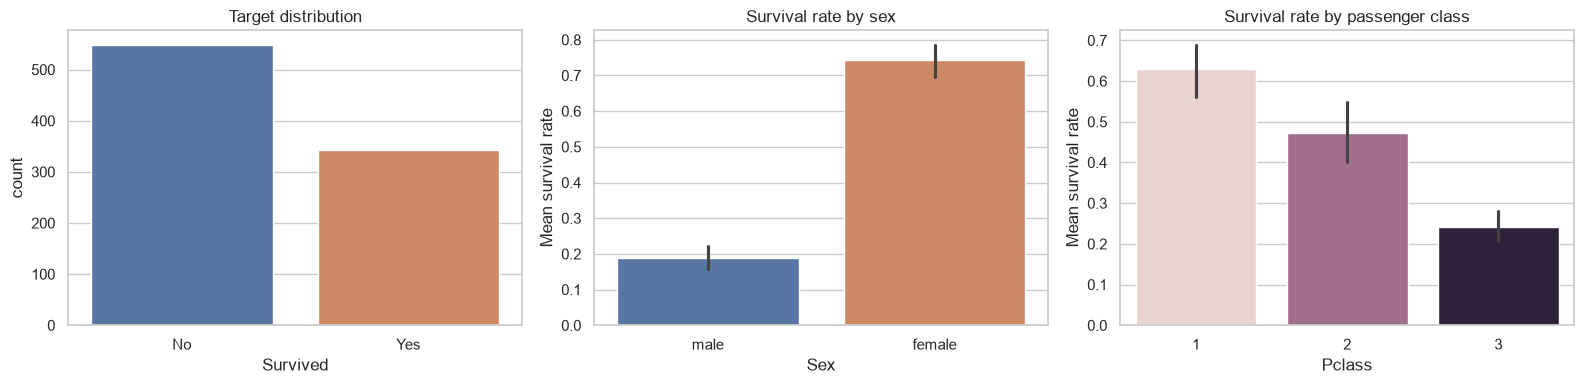

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="Survived", hue="Survived", legend=False, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xticks([0, 1], ["No", "Yes"])

sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", legend=False, ax=axes[1])
axes[1].set_title("Survival rate by sex")
axes[1].set_ylabel("Mean survival rate")

sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", legend=False, ax=axes[2])
axes[2].set_title("Survival rate by passenger class")
axes[2].set_ylabel("Mean survival rate")

plt.tight_layout()
plt.show()

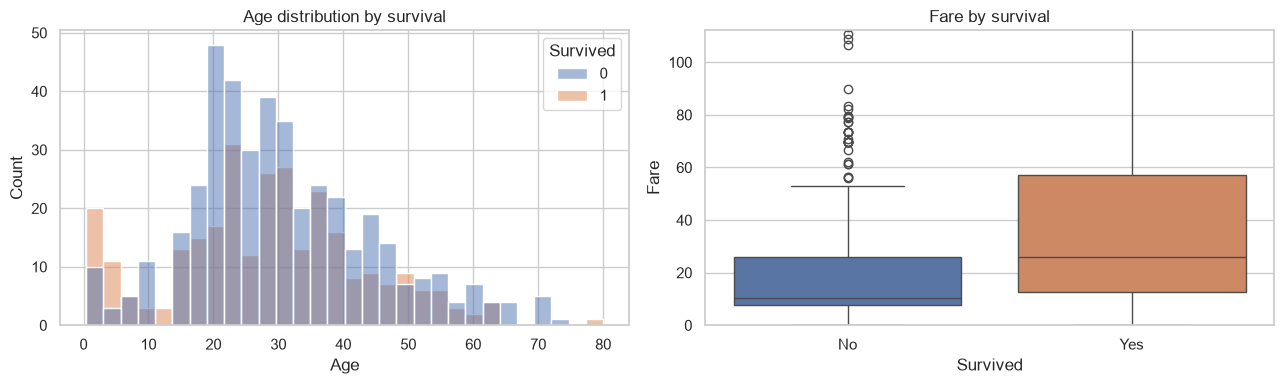

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, multiple="layer", ax=axes[0])
axes[0].set_title("Age distribution by survival")
sns.boxplot(data=df, x="Survived", y="Fare", hue="Survived", legend=False, ax=axes[1])
axes[1].set_title("Fare by survival")
axes[1].set_xticks([0, 1], ["No", "Yes"])
axes[1].set_ylim(0, df["Fare"].quantile(0.95))
plt.tight_layout()
plt.show()

### EDA interpretation

The target is moderately imbalanced: non-survivors are the majority. Survival rates also differ visibly by sex and passenger class, suggesting both features will be informative. Fare is right-skewed and contains extreme values; standardization will keep numeric features on comparable scales for the linear model. These are associations, not proof of causation.

## 4. Split before preprocessing

The test set is held out before any imputer, encoder, or scaler is fitted. `stratify=y` preserves the survival ratio in both sets. The pipeline later learns medians, modes, category levels, and scaling statistics from each training fold only, preventing data leakage.

In [7]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]
feature_columns = numeric_features + categorical_features

X = df[feature_columns].copy()
y = df["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Train survival rate: {y_train.mean():.3f}")
print(f"Test survival rate:  {y_test.mean():.3f}")

Training set: (712, 7)
Test set:     (179, 7)
Train survival rate: 0.383
Test survival rate:  0.385


## 5. Leakage-safe preprocessing

Numeric columns use median imputation followed by `StandardScaler`. Categorical columns use most-frequent imputation followed by one-hot encoding. Wrapping these steps in a `ColumnTransformer` and `Pipeline` guarantees that `fit` happens only on training data; the learned transformations are then applied unchanged to validation and test rows.

In [8]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

## 6. Compare a baseline and two models

The two candidate models are:

1. **Logistic regression** — a strong, interpretable baseline for binary classification.
2. **Random forest** — captures nonlinear relationships and feature interactions with few assumptions.

Model selection uses mean F1 from five-fold stratified cross-validation on the training set. The untouched test set is not used to choose the winner.

In [9]:
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=1)
    cv_rows.append({
        "model": name,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_cv_f1", ascending=False).reset_index(drop=True)
cv_results.style.format({"mean_cv_f1": "{:.3f}", "std_cv_f1": "{:.3f}"})

,model,mean_cv_f1,std_cv_f1
0,Random forest,0.749,0.032
1,Logistic regression,0.730,0.022
2,Dummy baseline,0.000,0.000


## 7. Final evaluation on unseen test data

All pipelines are fitted on the full training set and evaluated once on the held-out test set. The selected candidate remains the one with the highest training cross-validation F1, not whichever happens to score highest on the test set.

In [10]:
fitted_pipelines = {}
test_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    fitted_pipelines[name] = pipeline
    test_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    })

test_results = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_results.style.format({column: "{:.3f}" for column in test_results.columns if column != "model"})

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic regression,0.804,0.793,0.667,0.724,0.843
1,Random forest,0.804,0.815,0.638,0.715,0.840
2,Dummy baseline,0.615,0.000,0.000,0.000,0.500


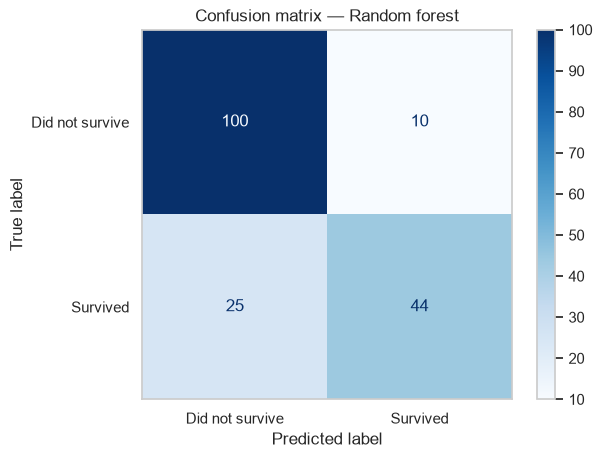

In [11]:
selected_name = cv_results.loc[
    cv_results["model"] != "Dummy baseline", "model"
].iloc[0]
selected_pipeline = fitted_pipelines[selected_name]
selected_predictions = selected_pipeline.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, selected_predictions, display_labels=["Did not survive", "Survived"], cmap="Blues"
)
plt.title(f"Confusion matrix — {selected_name}")
plt.grid(False)
plt.show()

## 8. Conclusion

Random forest was selected because it produced the best mean training cross-validation F1: **0.749 +/- 0.032**, compared with **0.730 +/- 0.022** for logistic regression and **0.000** for the dummy baseline. On the held-out test set, random forest achieved **0.715 F1**, **0.804 accuracy**, and **0.840 ROC AUC**, clearly beating the baseline's **0.000 F1**, **0.615 accuracy**, and **0.500 ROC AUC**.

Logistic regression happened to score slightly higher on test F1 (0.724), but switching models after seeing the test result would turn the test set into a selection set. Therefore, the random forest remains the honest pre-test choice. Both candidates used the same split and leakage-safe preprocessing workflow.

In [12]:
selected_cv = cv_results.set_index("model").loc[selected_name]
selected_test = test_results.set_index("model").loc[selected_name]
baseline_test = test_results.set_index("model").loc["Dummy baseline"]

print(f"Selected model: {selected_name}")
print(f"Mean cross-validation F1: {selected_cv['mean_cv_f1']:.3f} +/- {selected_cv['std_cv_f1']:.3f}")
print(f"Held-out test F1: {selected_test['f1']:.3f}")
print(f"Held-out test accuracy: {selected_test['accuracy']:.3f}")
print(f"Held-out test ROC AUC: {selected_test['roc_auc']:.3f}")
print(f"Dummy baseline test F1: {baseline_test['f1']:.3f}")
print()
print("Decision: choose the selected model because it had the strongest training CV F1 and clearly outperformed the baseline on unseen data.")

Selected model: Random forest
Mean cross-validation F1: 0.749 +/- 0.032
Held-out test F1: 0.715
Held-out test accuracy: 0.804
Held-out test ROC AUC: 0.840
Dummy baseline test F1: 0.000

Decision: choose the selected model because it had the strongest training CV F1 and clearly outperformed the baseline on unseen data.


### Limitations and next steps

This is a compact educational pipeline, not a deployment-ready system. The dataset is small, historical, and may contain social biases. Future work could engineer family-size or title features, tune hyperparameters using nested or training-only cross-validation, calibrate probabilities, and examine performance across passenger groups. The test set should remain untouched during those iterations.